# 📊 Exploratory Data Analysis (EDA)

## Objective

Analyze the merged movie dataset to understand:

- Distribution of movie ratings
- Most popular movies
- Language distribution
- Runtime distribution
- Budget and revenue patterns
- Missing values

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Plot style
plt.style.use("ggplot")

In [3]:
movies = pd.read_csv("../data/movies_merged.csv")

movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,spoken_languages,status,tagline,title_x,vote_average,vote_count,movie_id,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [4]:
print("Dataset Shape:", movies.shape)

Dataset Shape: (4803, 24)


In [5]:
movies.isnull().sum()

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title_x                    0
vote_average               0
vote_count                 0
movie_id                   0
title_y                    0
cast                       0
crew                       0
dtype: int64

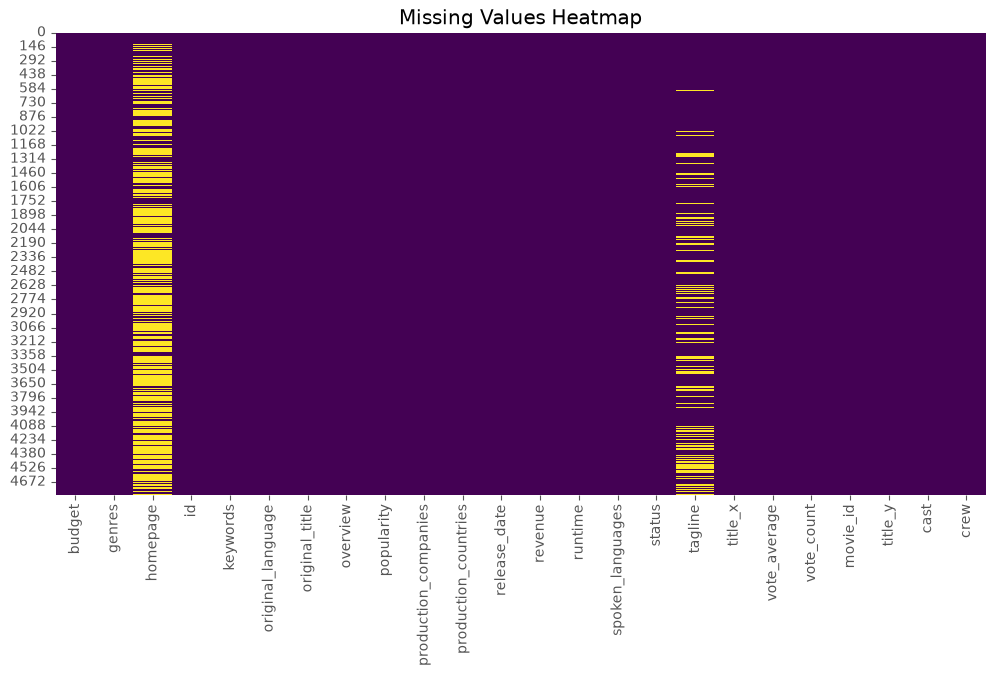

In [6]:
plt.figure(figsize=(12,6))

sns.heatmap(
    movies.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.show()

In [7]:
movies.duplicated().sum()

np.int64(0)

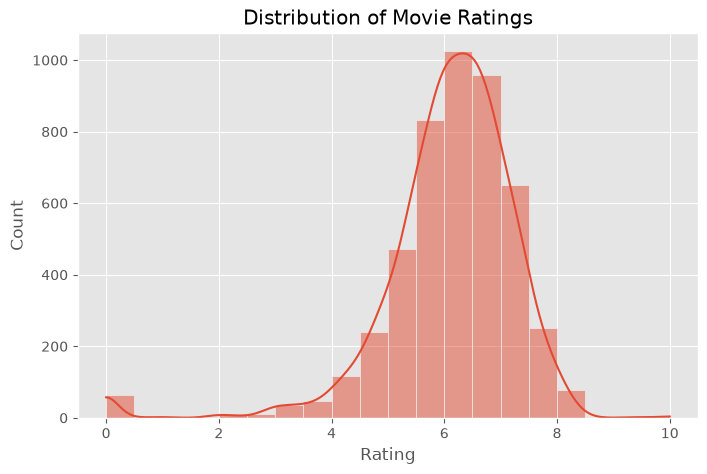

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    movies["vote_average"],
    bins=20,
    kde=True
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

In [9]:
top_movies = movies.sort_values(
    by="vote_average",
    ascending=False
)[["title_x","vote_average"]].head(10)

top_movies

,title_x,vote_average
4662,Little Big Top,10.0
3519,Stiff Upper Lips,10.0
4045,"Dancer, Texas Pop. 81",10.0
4247,Me You and Five Bucks,10.0
3992,Sardaarji,9.5
2386,One Man's Hero,9.3
1881,The Shawshank Redemption,8.5
2970,There Goes My Baby,8.5
3337,The Godfather,8.4
2796,The Prisoner of Zenda,8.4


In [10]:
top_popular = movies.sort_values(
    by="popularity",
    ascending=False
)[["title_x","popularity"]].head(10)

top_popular

,title_x,popularity
546,Minions,875.581305
95,Interstellar,724.247784
788,Deadpool,514.569956
94,Guardians of the Galaxy,481.098624
127,Mad Max: Fury Road,434.278564
28,Jurassic World,418.708552
199,Pirates of the Caribbean: The Curse of the Bla...,271.972889
82,Dawn of the Planet of the Apes,243.791743
200,The Hunger Games: Mockingjay - Part 1,206.227151
88,Big Hero 6,203.734590


C:\Users\SAI VARSHA\AppData\Local\Temp\ipykernel_28108\4226541838.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


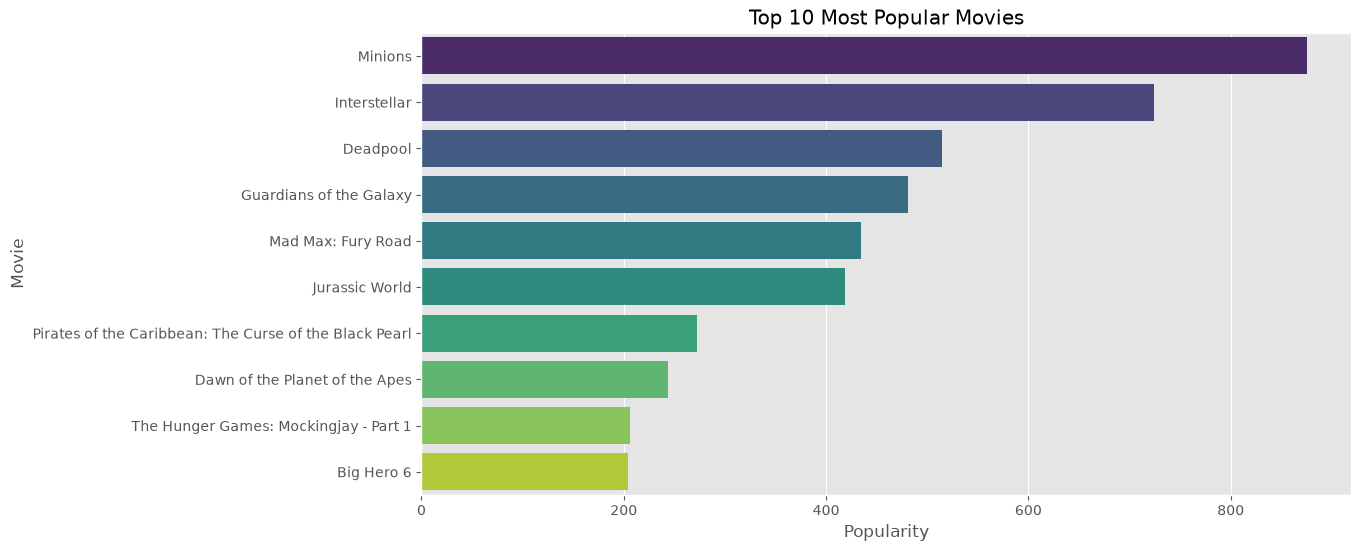

In [11]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_popular,
    x="popularity",
    y="title_x",
    palette="viridis"
)

plt.title("Top 10 Most Popular Movies")

plt.xlabel("Popularity")
plt.ylabel("Movie")

plt.show()

In [12]:
top_votes = movies.sort_values(
    by="vote_count",
    ascending=False
)[["title_x","vote_count"]].head(10)

top_votes

,title_x,vote_count
96,Inception,13752
65,The Dark Knight,12002
0,Avatar,11800
16,The Avengers,11776
788,Deadpool,10995
95,Interstellar,10867
287,Django Unchained,10099
94,Guardians of the Galaxy,9742
426,The Hunger Games,9455
127,Mad Max: Fury Road,9427


C:\Users\SAI VARSHA\AppData\Local\Temp\ipykernel_28108\2985444929.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


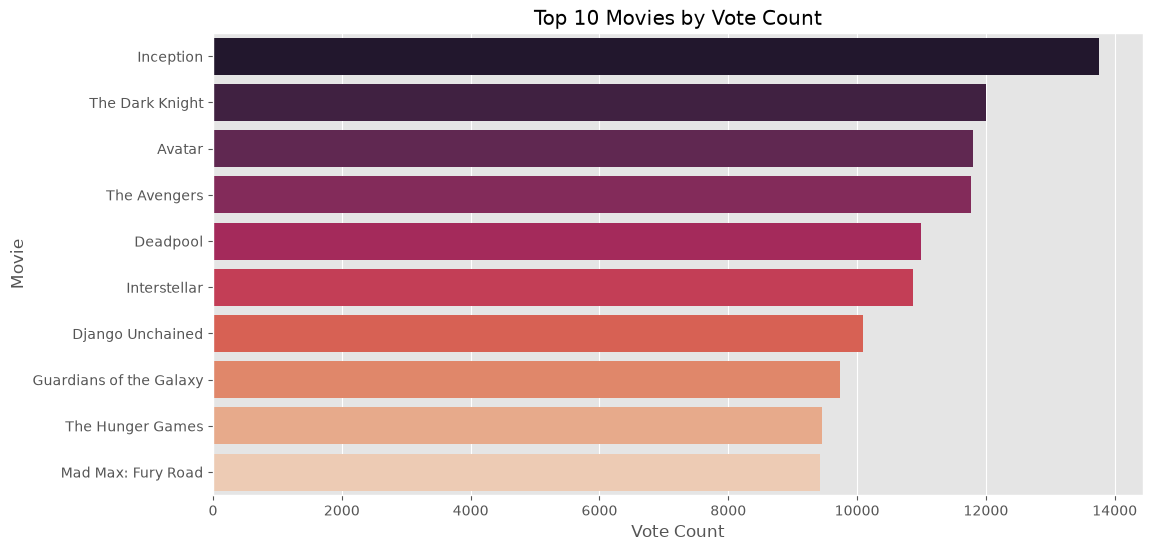

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_votes,
    x="vote_count",
    y="title_x",
    palette="rocket"
)

plt.title("Top 10 Movies by Vote Count")

plt.xlabel("Vote Count")
plt.ylabel("Movie")

plt.show()

In [14]:
movies["original_language"].value_counts().head(10)

original_language
en    4505
fr      70
es      32
zh      27
de      27
hi      19
ja      16
it      14
cn      12
ru      11
Name: count, dtype: int64

C:\Users\SAI VARSHA\AppData\Local\Temp\ipykernel_28108\872807457.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


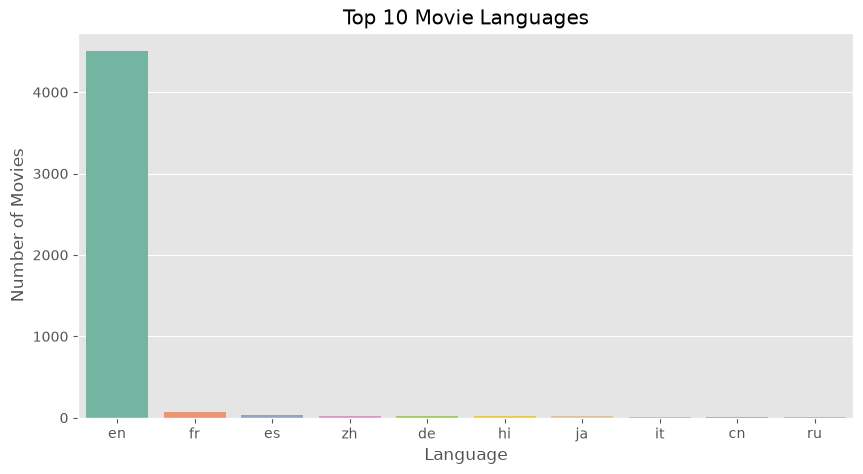

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=movies,
    x="original_language",
    order=movies["original_language"].value_counts().head(10).index,
    palette="Set2"
)

plt.title("Top 10 Movie Languages")

plt.xlabel("Language")

plt.ylabel("Number of Movies")

plt.show()

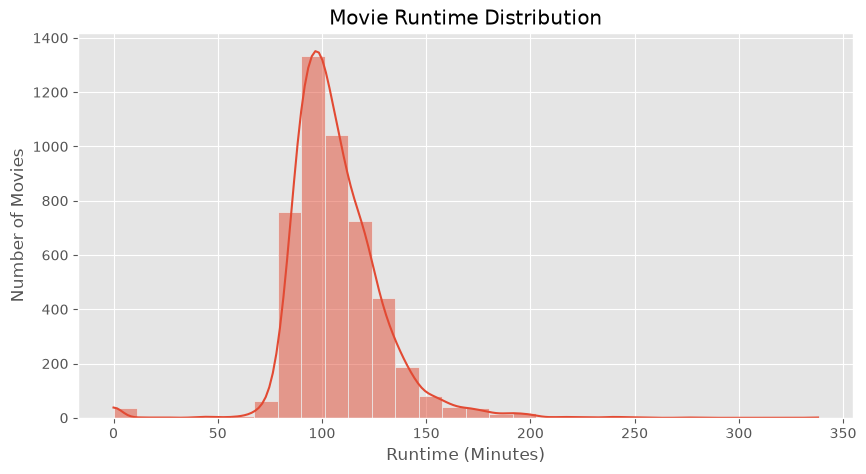

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    movies["runtime"],
    bins=30,
    kde=True
)

plt.title("Movie Runtime Distribution")
plt.xlabel("Runtime (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

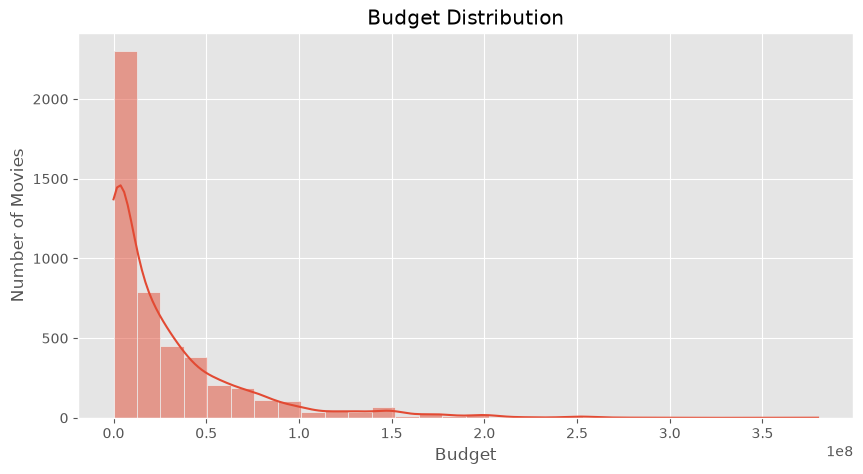

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    movies["budget"],
    bins=30,
    kde=True
)

plt.title("Budget Distribution")
plt.xlabel("Budget")
plt.ylabel("Number of Movies")

plt.show()

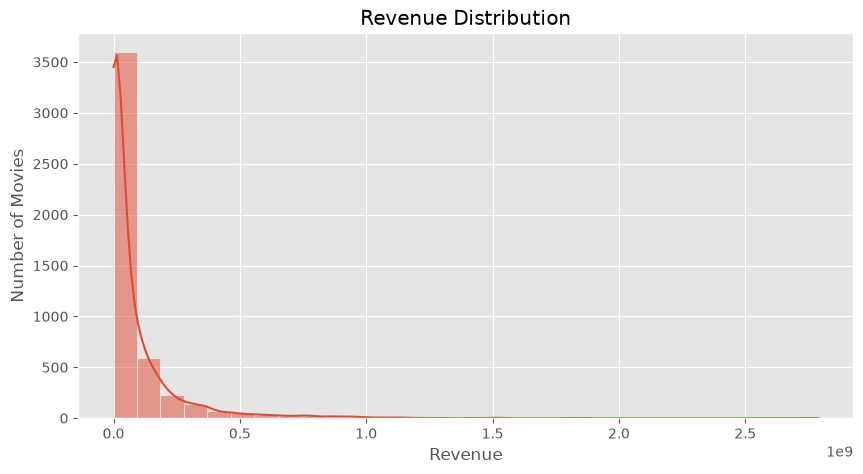

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(
    movies["revenue"],
    bins=30,
    kde=True
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Movies")

plt.show()

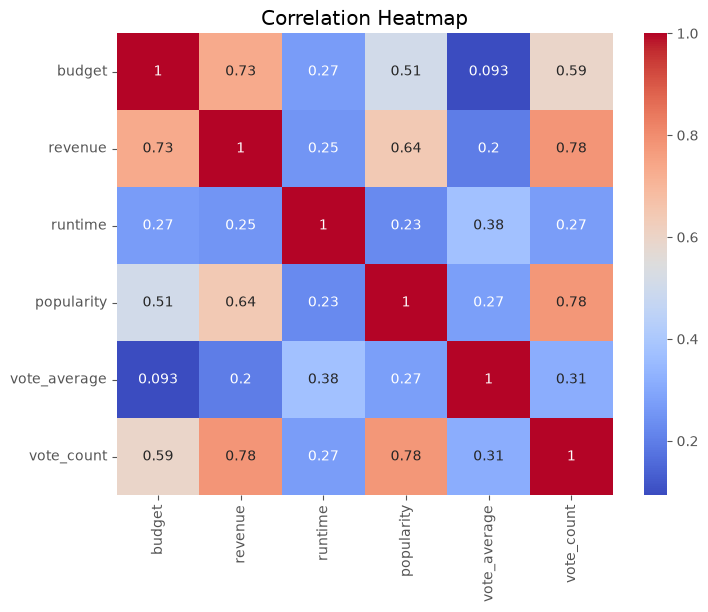

In [19]:
plt.figure(figsize=(8,6))

numeric_columns = [
    "budget",
    "revenue",
    "runtime",
    "popularity",
    "vote_average",
    "vote_count"
]

sns.heatmap(
    movies[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## EDA Summary

- The dataset contains 4,803 movies.
- English is the dominant language.
- Most movie ratings lie between 6 and 7.
- Movies such as **Minions**, **Interstellar**, and **Deadpool** are the most popular.
- **Inception**, **The Dark Knight**, and **Avatar** have the highest vote counts.
- Budget and revenue are positively correlated.
- The dataset contains missing values mainly in the homepage and tagline columns.